##### Aim
The project’s main use is to forecast short‑term stock direction predictionby using technical indicators like returns, moving averages volatility, RSI, MACD and machine‑learning models to predict whether the next day’s price will rise or fall.

##### Introduction
 I collected historical stock data from Yahoo Finance, created technical indicators like returns, moving averages, RSI, MACD, and volatility, and labeled each day as up or down based on a return threshold. Then I split the data in time order, trained multiple ML classifiers compared their performance using accuracy and balanced accuracy, selected the best model (XGBoost), and finally saved it for future use.

In [54]:
import yfinance as yf
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

In [55]:
# =========================
# 1. Download Data
# =========================
ticker ="TCS.NS"
df = yf.download(ticker, start="2014-01-01", end="2024-01-01")

[*********************100%***********************]  1 of 1 completed


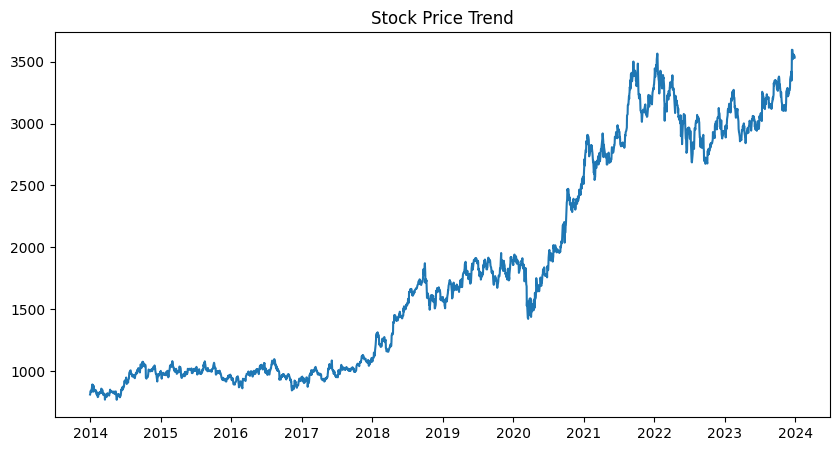

In [56]:
#  VISUALIZATION HERE
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(df["Close"])
plt.title("Stock Price Trend")
plt.show()

In [57]:
# =========================
# 2. Feature Engineering
# =========================
df["Return"] = df["Close"].pct_change()

df["Return_1"] = df["Return"].shift(1)
df["Return_3"] = df["Return"].rolling(3).mean()
df["Return_7"] = df["Return"].rolling(7).mean()

df["MA_10"] = df["Close"].rolling(10).mean()
df["MA_20"] = df["Close"].rolling(20).mean()
df["MA_50"] = df["Close"].rolling(50).mean()

df["Volatility_10"] = df["Return"].rolling(10).std()
df["Volatility_20"] = df["Return"].rolling(20).std()

In [58]:
# RSI
delta = df["Close"].diff()
gain = (delta.where(delta > 0, 0)).rolling(14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(14).mean()
rs = gain / loss
df["RSI"] = 100 - (100 / (1 + rs))

In [59]:
# MACD
ema12 = df["Close"].ewm(span=12, adjust=False).mean()
ema26 = df["Close"].ewm(span=26, adjust=False).mean()
df["MACD"] = ema12 - ema26

In [60]:
# =========================
# 3. Target
# =========================
threshold = 0.004
df["Target"] = ((df["Close"].shift(-1) - df["Close"]) / df["Close"] > threshold).astype(int)

df = df.dropna()

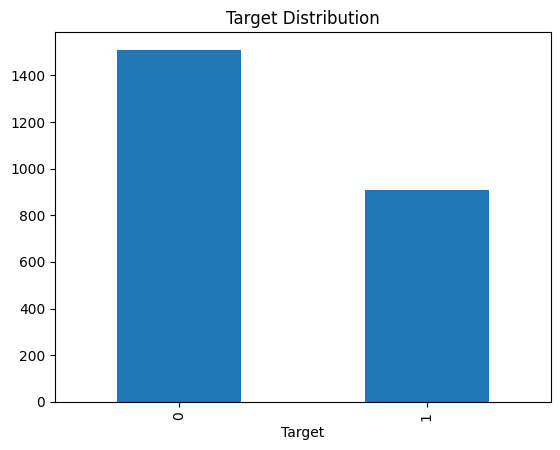

In [61]:
#  VISUALIZATION HERE
df["Target"].value_counts().plot(kind="bar")
plt.title("Target Distribution")
plt.show()

In [62]:
# =========================
# 4. Features
# =========================
features = [
    "Open","High","Low","Close","Volume",
    "MA_10","MA_20","MA_50",
    "Volatility_10","Volatility_20",
    "RSI","MACD",
    "Return_1","Return_3","Return_7"
]

X = df[features]
y = df["Target"]

In [63]:
# =========================
# 5. Split
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

In [64]:
# =========================
# 6. Models Dictionary
# =========================
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),

    "SVM": SVC(kernel='rbf', C=1, gamma='scale'),
    
      # 🔥 New Models
    "KNN": KNeighborsClassifier(n_neighbors=5),

    "XGBoost": XGBClassifier(
        n_estimators=500,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='logloss',
        random_state=42
    ),
    
    "Decision Tree": DecisionTreeClassifier(
        max_depth=5,
        min_samples_split=10,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        max_depth=8,
        min_samples_split=10,
        random_state=42,
        n_jobs=-1
    )

}

In [65]:
# =========================
# 7. Train & Compare
# =========================
results = []

for name, model in models.items():
    print(f"\n================ {name} ================")

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    bal_acc = balanced_accuracy_score(y_test, y_pred)

    print("Accuracy:", round(acc, 4))
    print("Balanced Accuracy:", round(bal_acc, 4))
    print(classification_report(y_test, y_pred))

    results.append([name, acc, bal_acc])


================ Logistic Regression ================
Accuracy: 0.6446
Balanced Accuracy: 0.502
              precision    recall  f1-score   support

           0       0.65      0.97      0.78       316
           1       0.38      0.04      0.07       168

    accuracy                           0.64       484
   macro avg       0.51      0.50      0.42       484
weighted avg       0.56      0.64      0.53       484


================ SVM ================
Accuracy: 0.6529
Balanced Accuracy: 0.5
              precision    recall  f1-score   support

           0       0.65      1.00      0.79       316
           1       0.00      0.00      0.00       168

    accuracy                           0.65       484
   macro avg       0.33      0.50      0.40       484
weighted avg       0.43      0.65      0.52       484


================ KNN ================
Accuracy: 0.5723
Balanced Accuracy: 0.4954
              precision    recall  f1-score   support

           0       0.65      0.75

c:\New folder\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\New folder\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\New folder\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Accuracy: 0.626
Balanced Accuracy: 0.5394
              precision    recall  f1-score   support

           0       0.68      0.82      0.74       316
           1       0.43      0.26      0.32       168

    accuracy                           0.63       484
   macro avg       0.55      0.54      0.53       484
weighted avg       0.59      0.63      0.60       484


================ Decision Tree ================
Accuracy: 0.5744
Balanced Accuracy: 0.4984
              precision    recall  f1-score   support

           0       0.65      0.75      0.70       316
           1       0.34      0.25      0.29       168

    accuracy                           0.57       484
   macro avg       0.50      0.50      0.49       484
weighted avg       0.55      0.57      0.56       484


================ Random Forest ================
Accuracy: 0.6467
Balanced Accuracy: 0.5022
              precision    recall  f1-score   support

           0       0.65      0.97      0.78       316
           

In [66]:
# =========================
# 8. Final Comparison Table
# =========================
results_df = pd.DataFrame(results, columns=["Model", "Accuracy", "Balanced Accuracy"])
results_df = results_df.sort_values(by="Balanced Accuracy", ascending=False)

print("\n🏆 FINAL MODEL COMPARISON")
print(results_df)


🏆 FINAL MODEL COMPARISON
                 Model  Accuracy  Balanced Accuracy
3              XGBoost  0.626033           0.539369
5        Random Forest  0.646694           0.502223
0  Logistic Regression  0.644628           0.502034
1                  SVM  0.652893           0.500000
4        Decision Tree  0.574380           0.498418
2                  KNN  0.572314           0.495442


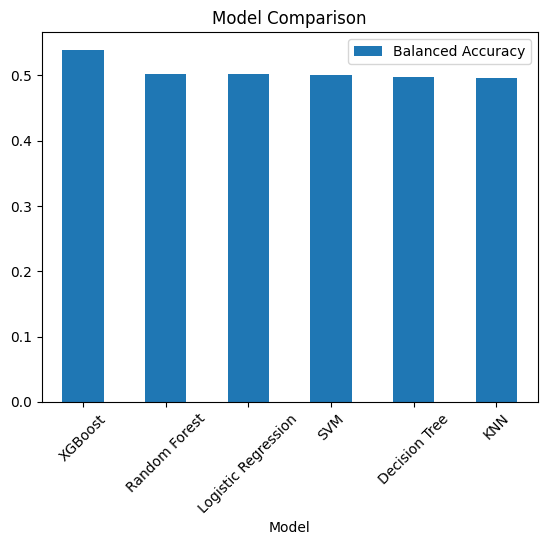

In [67]:
#  VISUALIZATION HERE
results_df.plot(x="Model", y="Balanced Accuracy", kind="bar")
plt.title("Model Comparison")
plt.xticks(rotation=45)
plt.show()

In [68]:
# =========================
# 9. Select XGBOOST Model
# =========================
xgboost = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42
)

# =========================
#   TRAIN MODEL 
# =========================
xgboost.fit(X_train, y_train)

#Probability Thresholding 
y_prob = model.predict_proba(X_test)[:,1]
y_pred = (y_prob > 0.38).astype(int)

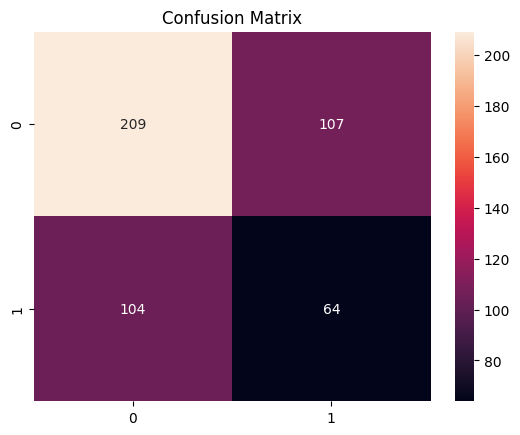

In [69]:
#  VISUALIZATION HERE
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

In [70]:
# =========================
# 10. Save Model
# =========================
import joblib
joblib.dump(xgboost, "xgboost.pkl")

['xgboost.pkl']

##### Conclusion
  This project shows that  data from Yahoo Finance price patterns and technical indicators can be used to build a machine‑learning model for short‑term stock direction. By comparing multiple classifiers, XGBoost performed best, and the final model was saved for reuse. Overall, it demonstrates an end‑to‑end ML pipeline from data collection to model deployment readiness.